# MaxViT による UTKFace データセットの学習

- 使用モデル：`maxvit_small_patch16_224`
- ハイパーパラメータ
  - `LR = 5e-5`
  - `BATCH_SIZE = 16`
  - `EPOCHS = 10`
  - `WEIGHT_DECAY = 1e-5`

## 1. 必要ライブラリのインポート

In [1]:
import multiprocessing as mp

mp.set_start_method("fork", force=True)
print(mp.get_start_method())

import re
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import timm
from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter Notebook 用の進捗バー
from tqdm.auto import tqdm
from IPython.display import display, clear_output

# 日本語文字化け対策
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams['font.family'] = ['IPAexGothic', 'Noto Sans CJK JP', 'MS Gothic', 'Hiragino Sans', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False

from safetensors.torch import save_file

fork


## 2. 再現性のためにシード値固定 および `DEVICE` の設定

In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = str(device)
print(f"Using device: {device}")

Using device: cuda


## 3. ハイパーパラメータやパスの設定

In [3]:
IMAGE_DIR = Path("../data/UTKFace")
MODEL_SAVE_DIR = Path("../models/maxvit-utkface")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "maxvit_small_tf_224"
IMG_SIZE = 224

# 今回は「人種(race)」5クラスを分類タスクの主軸とする
# 年齢・性別はマルチタスクヘッドで同時推論する
RACE_CLASSES = ["White", "Black", "Asian", "Indian", "Others"]
GENDER_CLASSES = ["Male", "Female"]
NUM_RACE_CLASSES = len(RACE_CLASSES)
NUM_GENDER_CLASSES = len(GENDER_CLASSES)

LR = 5e-5
BATCH_SIZE = 16
EPOCHS = 20
WEIGHT_DECAY = 1e-5
N_SPLITS = 5
NUM_WORKERS = 14  # Windows では 0 にしないとエラーが起きます
USE_FP16 = True

## 4. ファイル名のパースなど

In [4]:
# ===== UTKFace ファイル名のパース =====
# ファイル名: [age]_[gender]_[race]_[datetime].jpg

FNAME_PATTERN = re.compile(r"^(\d+)_(\d+)_(\d+)_(\d+)\.jpg(?:\.chip\.jpg)?$", re.IGNORECASE)

records = []
skipped = 0
for p in IMAGE_DIR.glob("*.jpg"):
    parts = p.name.split("_")
    if len(parts) < 4:
        skipped += 1
        continue
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
    except ValueError:
        skipped += 1
        continue
    if not (0 <= age <= 116) or gender not in (0, 1) or race not in (0, 1, 2, 3, 4):
        skipped += 1
        continue
    records.append({
        "path": str(p),
        "age": age,
        "gender": gender,
        "race": race,
    })

df = pd.DataFrame(records).reset_index(drop=True)
print(f"データ件数: {len(df)}（スキップ: {skipped}）")
print(df.head())

print("\n人種分布:")
print(df["race"].value_counts().sort_index())
print("\n性別分布:")
print(df["gender"].value_counts().sort_index())
print("\n年齢統計:")
print(df["age"].describe())

データ件数: 24102（スキップ: 4）
                                           path  age  gender  race
0  ../data/UTKFace/53_1_0_20170110141616567.jpg   53       1     0
1  ../data/UTKFace/29_0_0_20170109013328101.jpg   29       0     0
2  ../data/UTKFace/25_0_1_20170113151453752.jpg   25       0     1
3  ../data/UTKFace/26_0_3_20170104230310913.jpg   26       0     3
4  ../data/UTKFace/57_0_3_20170104212938069.jpg   57       0     3

人種分布:
race
0    10221
1     4558
2     3586
3     4027
4     1710
Name: count, dtype: int64

性別分布:
gender
0    12581
1    11521
Name: count, dtype: int64

年齢統計:
count    24102.000000
mean        33.041781
std         20.138950
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


## 5. `Dataset` の定義

In [5]:
class UTKFaceDataset(Dataset):
    """
    UTKFace データセット。
    画像を RGB で読み込み、(image, race, gender, age) を返す。
    主分類タスクは race（5クラス）。gender / age は補助ヘッドで学習。
    """
    def __init__(self, paths, races, genders, ages, transform=None):
        self.paths = paths
        self.races = races
        self.genders = genders
        self.ages = ages
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return (
            image,
            torch.tensor(self.races[idx], dtype=torch.long),
            torch.tensor(self.genders[idx], dtype=torch.long),
            torch.tensor(self.ages[idx], dtype=torch.float32),
        )


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

## 6. モデル定義（マルチタスク）

In [6]:
class MaxViTMultiTask(nn.Module):
    """
    MaxViT をバックボーンに、3つのヘッドを持つマルチタスクモデル。
      - race_head:   5クラス分類
      - gender_head: 2クラス分類
      - age_head:    回帰（1次元）
    """
    def __init__(self, model_name=MODEL_NAME, pretrained=True,
                 num_race=NUM_RACE_CLASSES, num_gender=NUM_GENDER_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,  # 特徴抽出器として使う
            global_pool="avg",
        )
        feat_dim = self.backbone.num_features

        self.race_head = nn.Linear(feat_dim, num_race)
        self.gender_head = nn.Linear(feat_dim, num_gender)
        self.age_head = nn.Linear(feat_dim, 1)

    def forward(self, x):
        feat = self.backbone(x)
        return self.race_head(feat), self.gender_head(feat), self.age_head(feat).squeeze(-1)

## 7. 学習・評価関数

In [7]:
def train_one_epoch(model, loader, ce_loss, mse_loss, optimizer, scaler,
                    device, use_fp16=True, pbar=None,
                    w_race=1.0, w_gender=0.5, w_age=0.05):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, races, genders, ages in loader:
        images = images.to(device, non_blocking=True)
        races = races.to(device, non_blocking=True)
        genders = genders.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        optimizer.zero_grad()

        if use_fp16:
            with autocast(DEVICE):
                race_out, gender_out, age_out = model(images)
                loss_race = ce_loss(race_out, races)
                loss_gender = ce_loss(gender_out, genders)
                loss_age = mse_loss(age_out, ages)
                loss = w_race * loss_race + w_gender * loss_gender + w_age * loss_age
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            race_out, gender_out, age_out = model(images)
            loss_race = ce_loss(race_out, races)
            loss_gender = ce_loss(gender_out, genders)
            loss_age = mse_loss(age_out, ages)
            loss = w_race * loss_race + w_gender * loss_gender + w_age * loss_age
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = race_out.max(1)
        correct += preds.eq(races).sum().item()
        total += races.size(0)

        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix({
                "loss": f"{running_loss / total:.4f}",
                "race_acc": f"{correct / total:.4f}",
            })

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, ce_loss, mse_loss, device, use_fp16=True, pbar=None,
             w_race=1.0, w_gender=0.5, w_age=0.05):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, races, genders, ages in loader:
        images = images.to(device, non_blocking=True)
        races = races.to(device, non_blocking=True)
        genders = genders.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        if use_fp16:
            with autocast(DEVICE):
                race_out, gender_out, age_out = model(images)
                loss_race = ce_loss(race_out, races)
                loss_gender = ce_loss(gender_out, genders)
                loss_age = mse_loss(age_out, ages)
                loss = w_race * loss_race + w_gender * loss_gender + w_age * loss_age
        else:
            race_out, gender_out, age_out = model(images)
            loss_race = ce_loss(race_out, races)
            loss_gender = ce_loss(gender_out, genders)
            loss_age = mse_loss(age_out, ages)
            loss = w_race * loss_race + w_gender * loss_gender + w_age * loss_age

        running_loss += loss.item() * images.size(0)
        _, preds = race_out.max(1)
        correct += preds.eq(races).sum().item()
        total += races.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(races.cpu().numpy())

        if pbar is not None:
            pbar.update(1)

    avg_loss = running_loss / total
    accuracy = correct / total
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, accuracy, macro_precision, macro_recall, macro_f1, all_preds, all_labels

## 8. 可視化関数

In [8]:
def plot_fold_history(history, fold_idx, epochs):
    """Fold 終了時に Loss / Accuracy / Macro F1 の学習曲線を描画。"""
    epochs_range = np.arange(1, epochs + 1)
    xticks = np.arange(0, epochs + 1, 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Loss ---
    ax = axes[0]
    ax.plot(epochs_range, history["train_loss"], color="green", linewidth=2, label="Train Loss")
    ax.plot(epochs_range, history["val_loss"],   color="red",   linewidth=2, label="Val Loss")
    ax.set_title(f"Fold {fold_idx + 1} - Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(xticks)
    ax.legend()
    ax.grid(alpha=0.3)

    # --- Accuracy ---
    ax = axes[1]
    ax.plot(epochs_range, history["train_acc"], color="green", linewidth=2, label="Train Accuracy")
    ax.plot(epochs_range, history["val_acc"],   color="red",   linewidth=2, label="Val Accuracy")
    ax.set_title(f"Fold {fold_idx + 1} - Accuracy (Race)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(xticks)
    ax.legend()
    ax.grid(alpha=0.3)

    # --- Macro F1 ---
    ax = axes[2]
    ax.plot(epochs_range, history["macro_f1"], color="orange", linewidth=2, label="Macro F1")
    ax.set_title(f"Fold {fold_idx + 1} - Macro F1 (Race)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro F1")
    ax.set_xticks(xticks)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def format_epoch_table(history_records):
    """各エポックの記録（list of dict）を DataFrame にして表示する。"""
    df_log = pd.DataFrame(history_records)
    cols = ["Epoch", "Train Loss", "Val Loss", "Train Acc", "Val Acc",
            "Precision", "Recall", "Macro F1"]
    df_log = df_log[cols]
    return df_log.style.format({
        "Train Loss": "{:.4f}",
        "Val Loss":   "{:.4f}",
        "Train Acc":  "{:.4f}",
        "Val Acc":    "{:.4f}",
        "Precision":  "{:.4f}",
        "Recall":     "{:.4f}",
        "Macro F1":   "{:.4f}",
    }).hide(axis="index")

## 9. 5分割交差検証

Cross-Validation:   0%|          | 0/5 [00:00<?, ?it/s]


Fold 1/5
Train: 19281 / Val: 4821


[Fold 1] Epoch 1/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 1] Epoch 1/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 21.7855 Acc: 0.4653 | Val Loss: 9.8338 Acc: 0.5895 | P: 0.4222 R: 0.4419 F1: 0.3829


...

[Fold 1] Epoch 19/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2501 Acc: 0.9895 | Val Loss: 3.0820 Acc: 0.8336 | P: 0.7876 R: 0.7502 F1: 0.7612


[Fold 1] Epoch 20/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 1] Epoch 20/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2437 Acc: 0.9889 | Val Loss: 3.1835 Acc: 0.8276 | P: 0.7707 R: 0.7520 F1: 0.7598


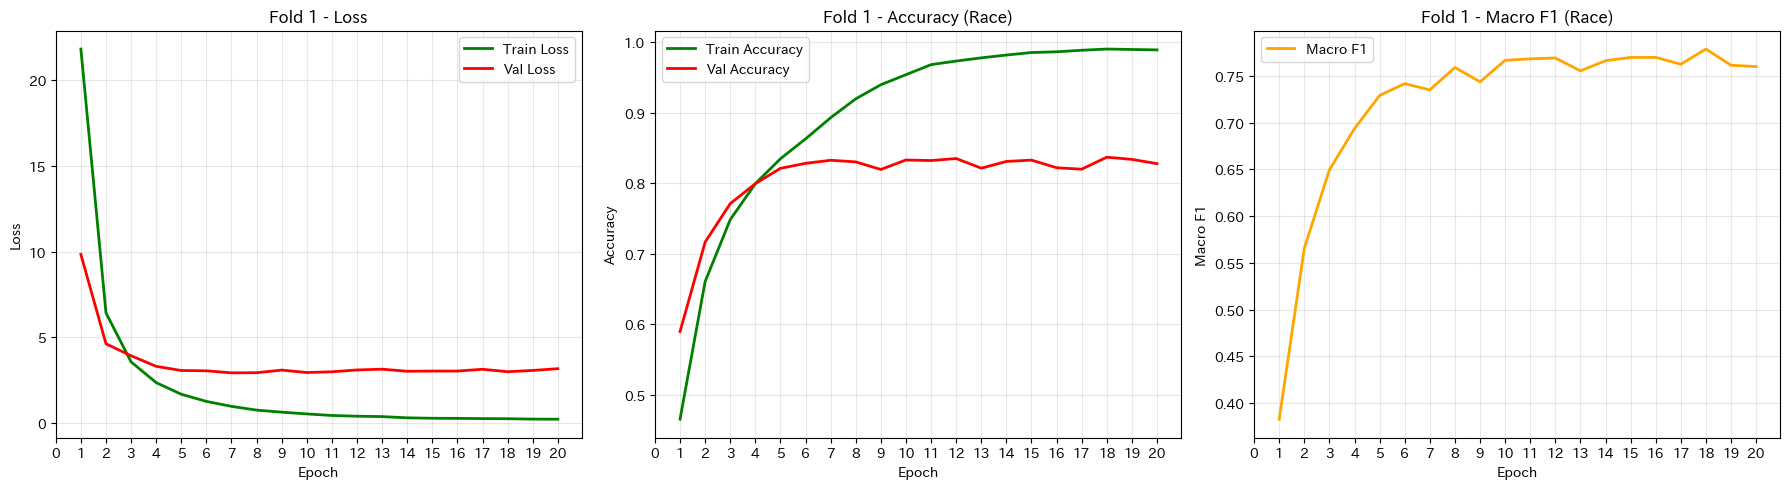

Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Precision,Recall,Macro F1
1,21.7855,9.8338,0.4653,0.5895,0.4222,0.4419,0.3829
2,6.4319,4.6328,0.6605,0.7164,0.7427,0.5654,0.5655
3,3.5790,3.9364,0.7482,0.7710,0.7006,0.6560,0.6494
4,2.3722,3.3210,0.7992,0.7992,0.7551,0.6880,0.6936
5,1.6961,3.0790,0.8346,0.8210,0.7574,0.7256,0.7289
6,1.2795,3.0600,0.8627,0.8280,0.7746,0.7391,0.7416
7,0.9911,2.9423,0.8927,0.8324,0.7806,0.7319,0.7349
8,0.7731,2.9504,0.9195,0.8301,0.7700,0.7535,0.7589
9,0.6535,3.1021,0.9395,0.8193,0.7851,0.7169,0.7435
10,0.5516,2.9605,0.9537,0.8328,0.7753,0.7589,0.7665


★ Best fold updated: Fold 1 (Macro F1 = 0.7598)

Fold 2/5
Train: 19281 / Val: 4821


[Fold 2] Epoch 1/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 2] Epoch 1/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 23.4159 Acc: 0.4378 | Val Loss: 10.3473 Acc: 0.5509 | P: 0.4457 R: 0.3672 F1: 0.3434


...

[Fold 2] Epoch 19/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2498 Acc: 0.9901 | Val Loss: 3.1289 Acc: 0.8303 | P: 0.7659 R: 0.7724 F1: 0.7689


[Fold 2] Epoch 20/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 2] Epoch 20/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2319 Acc: 0.9926 | Val Loss: 3.1250 Acc: 0.8303 | P: 0.7760 R: 0.7604 F1: 0.7675


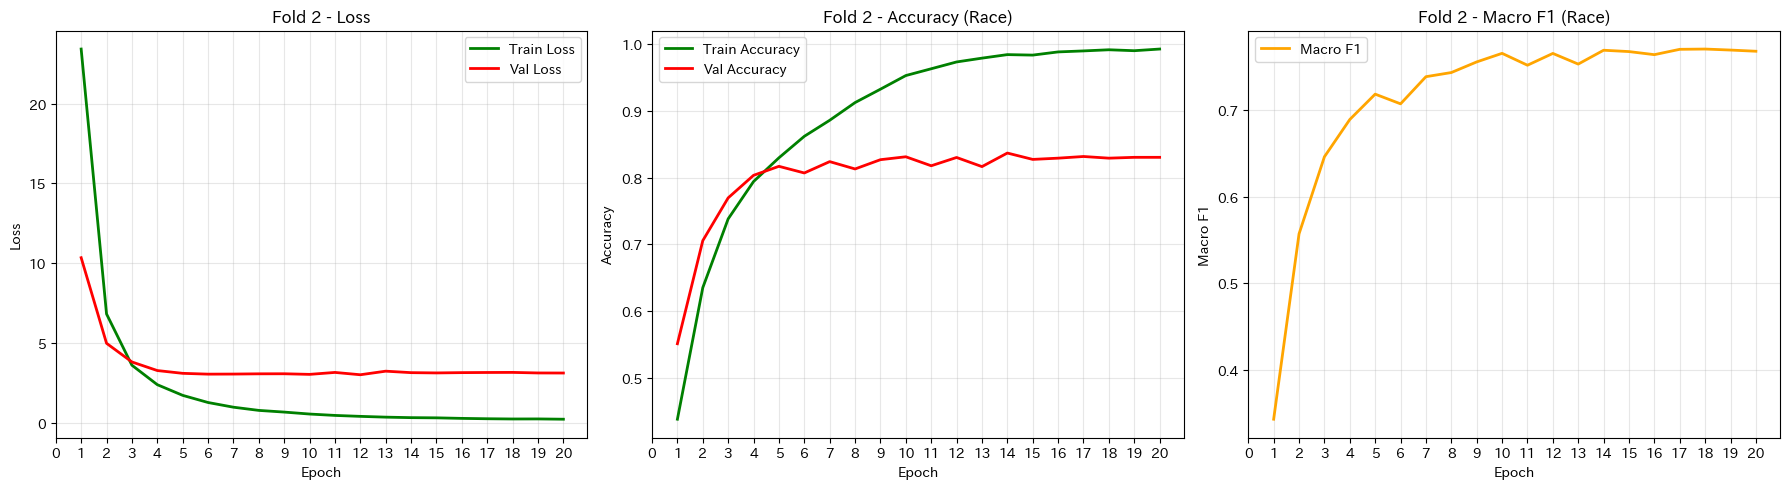

Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Precision,Recall,Macro F1
1,23.4159,10.3473,0.4378,0.5509,0.4457,0.3672,0.3434
2,6.8239,4.9871,0.6350,0.7055,0.7396,0.5682,0.5570
3,3.6135,3.8180,0.7381,0.7695,0.6824,0.6513,0.6459
4,2.3950,3.2799,0.7940,0.8034,0.7304,0.6864,0.6889
5,1.7261,3.1053,0.8296,0.8168,0.7371,0.7167,0.7181
6,1.2782,3.0545,0.8618,0.8069,0.7285,0.7133,0.7069
7,0.9843,3.0596,0.8858,0.8239,0.7570,0.7318,0.7382
8,0.7839,3.0749,0.9124,0.8129,0.7576,0.7320,0.7430
9,0.6785,3.0785,0.9325,0.8268,0.7622,0.7516,0.7552
10,0.5562,3.0402,0.9529,0.8312,0.7746,0.7578,0.7651


★ Best fold updated: Fold 2 (Macro F1 = 0.7675)

Fold 3/5
Train: 19282 / Val: 4820


[Fold 3] Epoch 1/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 3] Epoch 1/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 21.4571 Acc: 0.4561 | Val Loss: 9.4402 Acc: 0.5595 | P: 0.4327 R: 0.3852 F1: 0.3596


...

[Fold 3] Epoch 19/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2427 Acc: 0.9915 | Val Loss: 3.2646 Acc: 0.8315 | P: 0.7758 R: 0.7602 F1: 0.7668


[Fold 3] Epoch 20/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 3] Epoch 20/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2419 Acc: 0.9892 | Val Loss: 3.2721 Acc: 0.8220 | P: 0.7652 R: 0.7748 F1: 0.7668


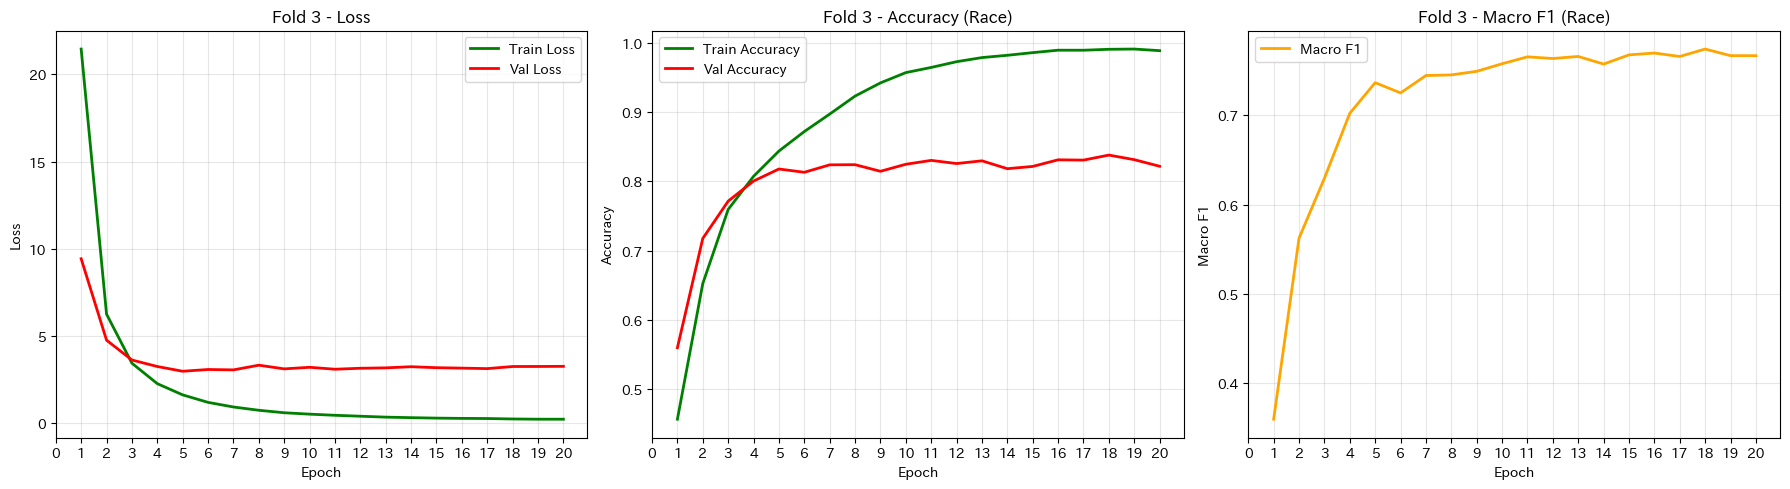

Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Precision,Recall,Macro F1
1,21.4571,9.4402,0.4561,0.5595,0.4327,0.3852,0.3596
2,6.2644,4.7725,0.6523,0.7176,0.6167,0.5662,0.5624
3,3.4516,3.6351,0.7595,0.7716,0.6855,0.6342,0.6295
4,2.2801,3.2623,0.8074,0.8006,0.7359,0.6984,0.7023
5,1.6367,2.9905,0.8440,0.8180,0.7568,0.7274,0.7366
6,1.2072,3.0913,0.8722,0.8133,0.7700,0.7058,0.7251
7,0.9424,3.0691,0.8975,0.8241,0.7635,0.7325,0.7446
8,0.7543,3.3382,0.9235,0.8243,0.7684,0.7292,0.7453
9,0.6124,3.1272,0.9426,0.8147,0.7531,0.7480,0.7493
10,0.5321,3.2177,0.9575,0.8249,0.7651,0.7519,0.7578



Fold 4/5
Train: 19282 / Val: 4820


[Fold 4] Epoch 1/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 4] Epoch 1/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 21.8817 Acc: 0.4424 | Val Loss: 9.2472 Acc: 0.5351 | P: 0.4001 R: 0.3645 F1: 0.3388


...

[Fold 4] Epoch 19/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2247 Acc: 0.9911 | Val Loss: 3.1690 Acc: 0.8251 | P: 0.7602 R: 0.7796 F1: 0.7683


[Fold 4] Epoch 20/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 4] Epoch 20/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2268 Acc: 0.9914 | Val Loss: 3.2438 Acc: 0.8274 | P: 0.7765 R: 0.7730 F1: 0.7716


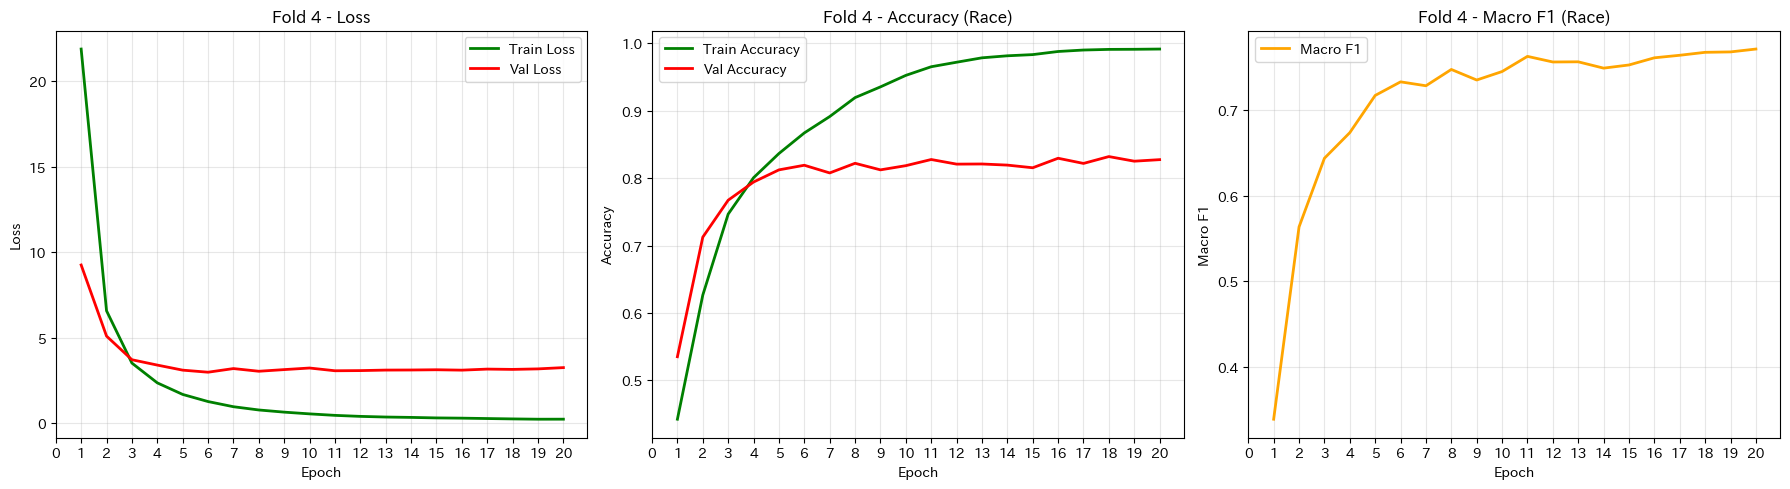

Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Precision,Recall,Macro F1
1,21.8817,9.2472,0.4424,0.5351,0.4001,0.3645,0.3388
2,6.5677,5.0871,0.6265,0.7124,0.6289,0.5749,0.5636
3,3.5085,3.7047,0.7466,0.7672,0.7049,0.6403,0.6439
4,2.3517,3.3917,0.8006,0.7942,0.7424,0.6652,0.6739
5,1.6748,3.0954,0.8365,0.8122,0.7639,0.7071,0.7174
6,1.2581,2.9748,0.8670,0.8191,0.7595,0.7299,0.7333
7,0.9554,3.1875,0.8913,0.8077,0.7318,0.7370,0.7287
8,0.7651,3.0305,0.9194,0.8220,0.7718,0.7316,0.7477
9,0.6384,3.1272,0.9353,0.8122,0.7475,0.7308,0.7354
10,0.5370,3.2198,0.9524,0.8185,0.7773,0.7239,0.7453


★ Best fold updated: Fold 4 (Macro F1 = 0.7716)

Fold 5/5
Train: 19282 / Val: 4820


[Fold 5] Epoch 1/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 5] Epoch 1/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 23.6832 Acc: 0.4297 | Val Loss: 10.3947 Acc: 0.5257 | P: 0.3883 R: 0.3487 F1: 0.3288


...

[Fold 5] Epoch 19/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2432 Acc: 0.9903 | Val Loss: 3.1529 Acc: 0.8197 | P: 0.7553 R: 0.7665 F1: 0.7597


[Fold 5] Epoch 20/20 Train:   0%|          | 0/1206 [00:00<?, ?it/s]

[Fold 5] Epoch 20/20 Val:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.2246 Acc: 0.9921 | Val Loss: 3.1732 Acc: 0.8305 | P: 0.7722 R: 0.7563 F1: 0.7634


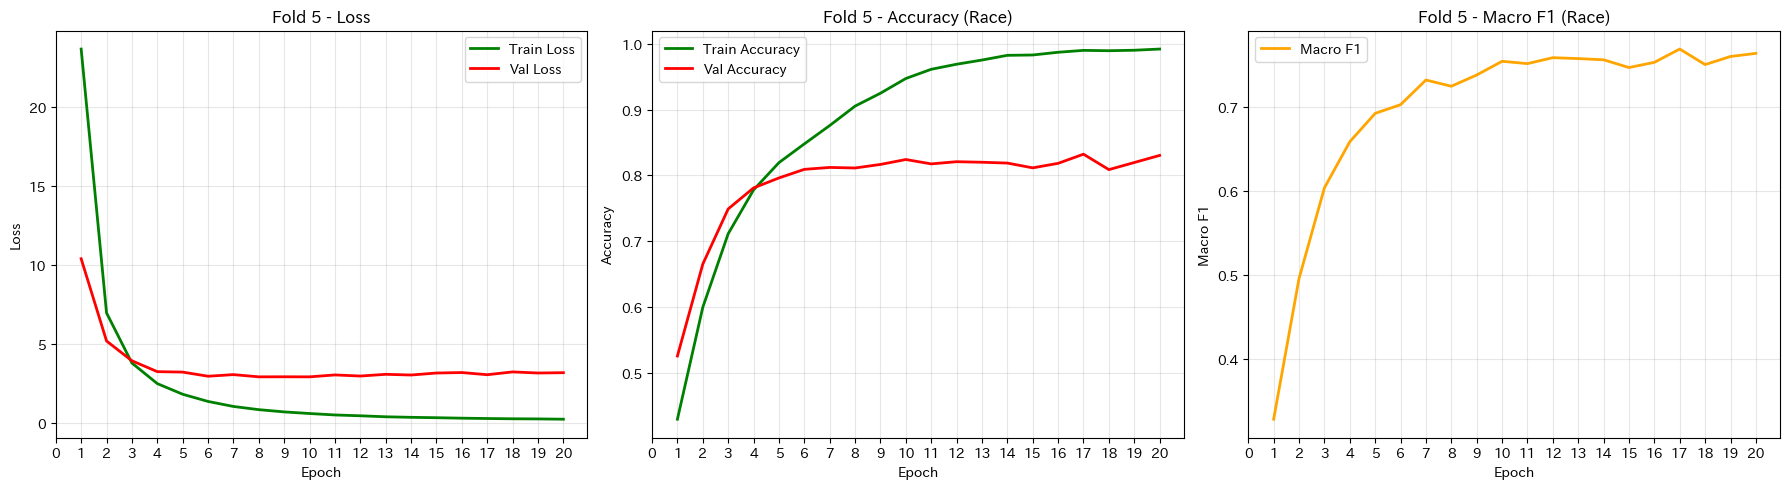

Epoch,Train Loss,Val Loss,Train Acc,Val Acc,Precision,Recall,Macro F1
1,23.6832,10.3947,0.4297,0.5257,0.3883,0.3487,0.3288
2,6.9623,5.1819,0.5997,0.6654,0.5073,0.5109,0.4960
3,3.7849,3.9273,0.7114,0.7492,0.6849,0.6103,0.6037
4,2.4819,3.2389,0.7781,0.7811,0.7166,0.6554,0.6585
5,1.8066,3.2103,0.8195,0.7963,0.7276,0.6980,0.6922
6,1.3503,2.9487,0.8480,0.8093,0.7398,0.6960,0.7025
7,1.0328,3.0508,0.8759,0.8122,0.7499,0.7307,0.7318
8,0.8300,2.9098,0.9054,0.8114,0.7551,0.7171,0.7244
9,0.6877,2.9136,0.9250,0.8168,0.7603,0.7260,0.7377
10,0.5855,2.9096,0.9474,0.8243,0.7596,0.7498,0.7540



Cross-Validation 完了


In [9]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

paths_all = df["path"].values
races_all = df["race"].values
genders_all = df["gender"].values
ages_all = df["age"].values

fold_histories = []
fold_final_metrics = []
fold_predictions = []
best_fold_idx = -1
best_macro_f1 = -1.0
best_model_state = None

fold_bar = tqdm(total=N_SPLITS, desc="Cross-Validation", position=0, leave=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(paths_all, races_all)):
    print(f"\n{'='*70}")
    print(f"Fold {fold + 1}/{N_SPLITS}")
    print(f"{'='*70}")

    train_paths = paths_all[train_idx]
    train_races = races_all[train_idx]
    train_genders = genders_all[train_idx]
    train_ages = ages_all[train_idx]

    val_paths = paths_all[val_idx]
    val_races = races_all[val_idx]
    val_genders = genders_all[val_idx]
    val_ages = ages_all[val_idx]

    train_dataset = UTKFaceDataset(train_paths, train_races, train_genders, train_ages, transform=train_transform)
    val_dataset   = UTKFaceDataset(val_paths,   val_races,   val_genders,   val_ages,   transform=val_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS > 0),
    )

    print(f"Train: {len(train_dataset)} / Val: {len(val_dataset)}")

    # --- Model / Optimizer / Loss ---
    model = MaxViTMultiTask(model_name=MODEL_NAME, pretrained=True).to(device)
    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = GradScaler(DEVICE, enabled=USE_FP16)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "macro_f1":   [],
    }
    epoch_records = []

    last_preds = None
    last_labels = None

    for epoch in range(1, EPOCHS + 1):
        # --- 進捗バー ---
        train_pbar = tqdm(total=len(train_loader),
                          desc=f"[Fold {fold+1}] Epoch {epoch}/{EPOCHS} Train",
                          leave=False)
        val_pbar = tqdm(total=len(val_loader),
                        desc=f"[Fold {fold+1}] Epoch {epoch}/{EPOCHS} Val",
                        leave=False)

        train_loss, train_acc = train_one_epoch(
            model, train_loader, ce_loss, mse_loss, optimizer, scaler,
            device, use_fp16=USE_FP16, pbar=train_pbar,
        )
        train_pbar.close()

        val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = evaluate(
            model, val_loader, ce_loss, mse_loss, device,
            use_fp16=USE_FP16, pbar=val_pbar,
        )
        val_pbar.close()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["macro_f1"].append(val_f1)

        epoch_records.append({
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Val Loss":   val_loss,
            "Train Acc":  train_acc,
            "Val Acc":    val_acc,
            "Precision":  val_prec,
            "Recall":     val_rec,
            "Macro F1":   val_f1,
        })

        last_preds = val_preds
        last_labels = val_labels

        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"P: {val_prec:.4f} R: {val_rec:.4f} F1: {val_f1:.4f}")

    # --- Fold 終了時の可視化 ---
    plot_fold_history(history, fold, EPOCHS)
    display(format_epoch_table(epoch_records))

    fold_histories.append(history)
    fold_predictions.append((last_preds, last_labels))

    final_f1 = history["macro_f1"][-1]
    fold_final_metrics.append({
        "Fold": fold + 1,
        "Train Loss": history["train_loss"][-1],
        "Val Loss":   history["val_loss"][-1],
        "Train Acc":  history["train_acc"][-1],
        "Val Acc":    history["val_acc"][-1],
        "Macro F1":   final_f1,
    })

    if final_f1 > best_macro_f1:
        best_macro_f1 = final_f1
        best_fold_idx = fold
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"★ Best fold updated: Fold {fold+1} (Macro F1 = {final_f1:.4f})")

    # メモリ解放
    del model, optimizer, scaler, train_loader, val_loader, train_dataset, val_dataset
    torch.cuda.empty_cache()

    fold_bar.update(1)

fold_bar.close()
print("\nCross-Validation 完了")

## 10. 全Foldの平均曲線を描画

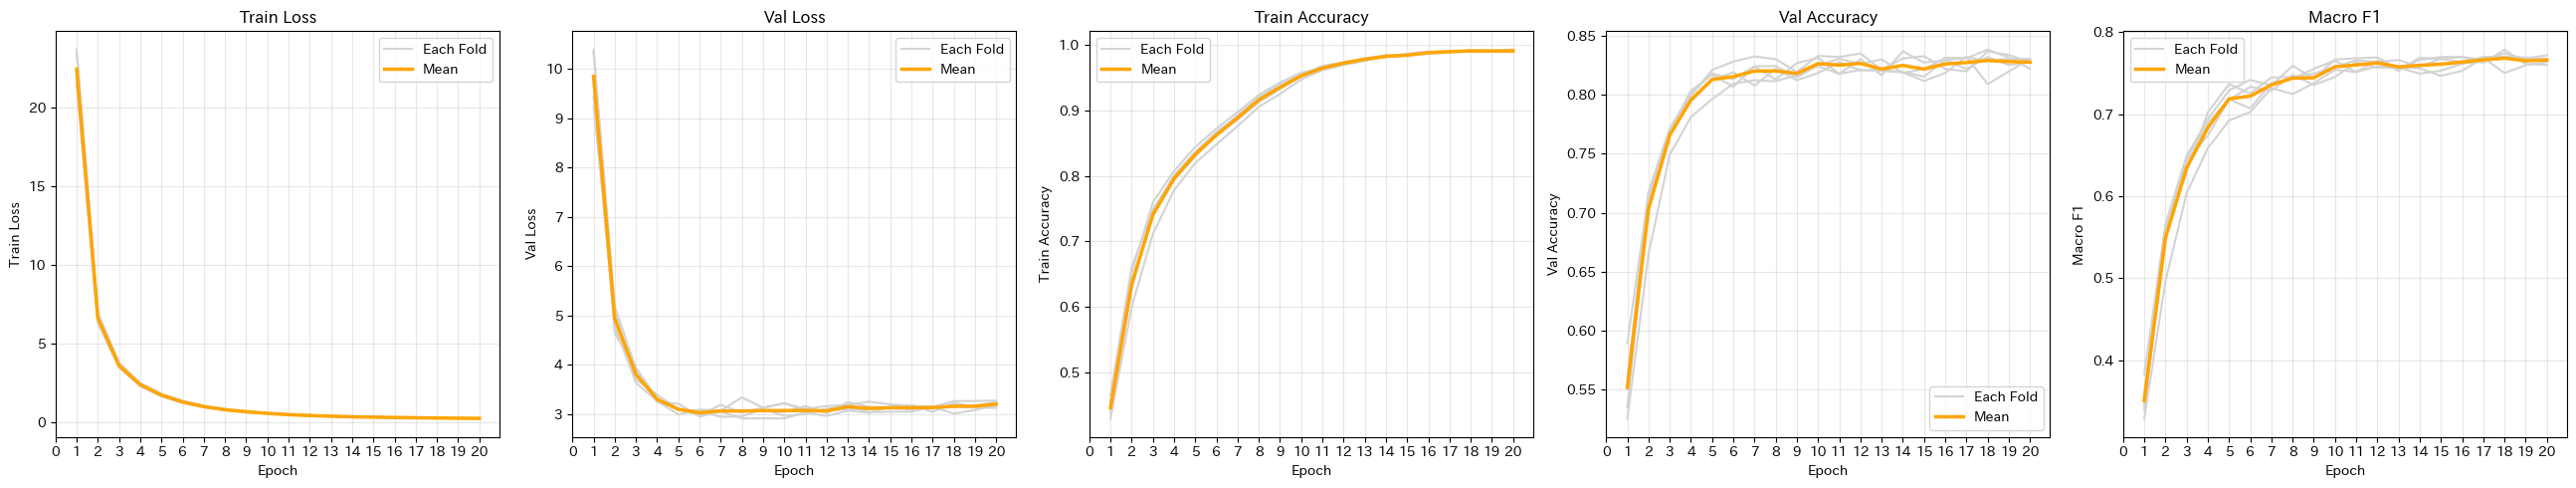

Fold,Train Loss,Val Loss,Train Acc,Val Acc,Macro F1
1,0.2437,3.1835,0.9889,0.8276,0.7598
2,0.2319,3.1250,0.9926,0.8303,0.7675
3,0.2419,3.2721,0.9892,0.8220,0.7668
4,0.2268,3.2438,0.9914,0.8274,0.7716
5,0.2246,3.1732,0.9921,0.8305,0.7634



Mean Macro F1: 0.7658 ± 0.0044
Best Fold: 4 (Macro F1 = 0.7716)


In [10]:
def plot_average_history(fold_histories, epochs):
    epochs_range = np.arange(1, epochs + 1)
    xticks = np.arange(0, epochs + 1, 1)

    metrics = [
        ("train_loss", "Train Loss"),
        ("val_loss",   "Val Loss"),
        ("train_acc",  "Train Accuracy"),
        ("val_acc",    "Val Accuracy"),
        ("macro_f1",   "Macro F1"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(26, 5))

    for ax, (key, title) in zip(axes, metrics):
        stack = np.array([h[key] for h in fold_histories])  # (n_folds, epochs)
        mean_curve = stack.mean(axis=0)

        for i in range(stack.shape[0]):
            ax.plot(epochs_range, stack[i], color="lightgray", linewidth=1.5,
                    label="Each Fold" if i == 0 else None)
        ax.plot(epochs_range, mean_curve, color="orange", linewidth=2.5, label="Mean")

        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_xticks(xticks)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_average_history(fold_histories, EPOCHS)

# Fold ごとの最終メトリクス
df_fold = pd.DataFrame(fold_final_metrics)
display(df_fold.style.format({
    "Train Loss": "{:.4f}", "Val Loss": "{:.4f}",
    "Train Acc":  "{:.4f}", "Val Acc":  "{:.4f}",
    "Macro F1":   "{:.4f}",
}).hide(axis="index"))

print(f"\nMean Macro F1: {df_fold['Macro F1'].mean():.4f} ± {df_fold['Macro F1'].std():.4f}")
print(f"Best Fold: {best_fold_idx + 1} (Macro F1 = {best_macro_f1:.4f})")

## 11. Best Fold の混同行列

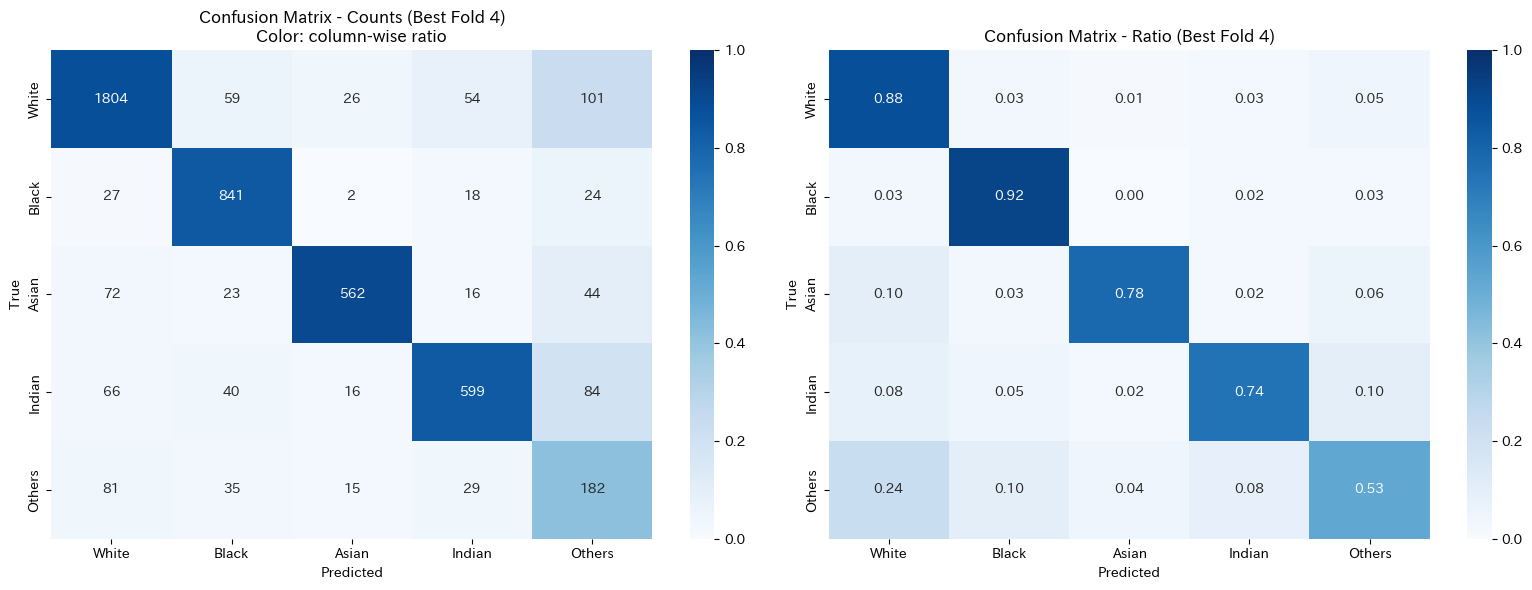


Classification Report (Best Fold):
              precision    recall  f1-score   support

       White       0.88      0.88      0.88      2044
       Black       0.84      0.92      0.88       912
       Asian       0.90      0.78      0.84       717
      Indian       0.84      0.74      0.79       805
      Others       0.42      0.53      0.47       342

    accuracy                           0.83      4820
   macro avg       0.78      0.77      0.77      4820
weighted avg       0.84      0.83      0.83      4820



In [11]:
best_preds, best_labels = fold_predictions[best_fold_idx]
cm = confusion_matrix(best_labels, best_preds, labels=list(range(NUM_RACE_CLASSES)))

# 列ごとの割合（各予測クラスに対する正解の分布）で色付け
col_sums = cm.sum(axis=0, keepdims=True)
col_sums[col_sums == 0] = 1
cm_col_ratio = cm / col_sums  # 列方向の割合

# 行ごとの割合（真クラスごとの予測分布）= 通常の正規化混同行列
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_row_ratio = cm / row_sums

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 件数（色付けは列ごとの割合）
ax = axes[0]
sns.heatmap(cm_col_ratio, annot=cm, fmt="d", cmap="Blues",
            xticklabels=RACE_CLASSES, yticklabels=RACE_CLASSES,
            cbar=True, ax=ax, vmin=0, vmax=1)
ax.set_title(f"Confusion Matrix - Counts (Best Fold {best_fold_idx + 1})\nColor: column-wise ratio")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# 右: 割合（行ごとの割合）
ax = axes[1]
sns.heatmap(cm_row_ratio, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=RACE_CLASSES, yticklabels=RACE_CLASSES,
            cbar=True, ax=ax, vmin=0, vmax=1)
ax.set_title(f"Confusion Matrix - Ratio (Best Fold {best_fold_idx + 1})")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.show()

print("\nClassification Report (Best Fold):")
print(classification_report(best_labels, best_preds, target_names=RACE_CLASSES, zero_division=0))

## 12. Best Fold を `.safetensors` 形式で保存

In [12]:
if best_model_state is None:
    raise RuntimeError("Best model state が見つかりません。")

save_path = MODEL_SAVE_DIR / f"maxvit_utkface_best_fold{best_fold_idx + 1}.safetensors"
# safetensors は contiguous な tensor を要求するので変換しておく
state_to_save = {k: v.contiguous() for k, v in best_model_state.items()}
save_file(state_to_save, str(save_path))

# 推論時に必要となるメタ情報も併せて保存
meta = {
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "race_classes": RACE_CLASSES,
    "gender_classes": GENDER_CLASSES,
    "best_fold": best_fold_idx + 1,
    "best_macro_f1": float(best_macro_f1),
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std":  [0.229, 0.224, 0.225],
}
import json
with open(MODEL_SAVE_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"Saved: {save_path}")
print(f"Saved meta: {MODEL_SAVE_DIR / 'meta.json'}")

Saved: ../models/maxvit-utkface/maxvit_utkface_best_fold4.safetensors
Saved meta: ../models/maxvit-utkface/meta.json
